# TuSimple Testing Notebook

This notebook evaluates a trained LaneNet or LaneNetResNet34 checkpoint on the TuSimple dataset using TuSimple-style lane detection metrics: accuracy, false positive rate, and false negative rate. It also saves predictions in a JSON-lines format similar to the TuSimple submission format.

In [1]:
!nvidia-smi --query-gpu=name --format=csv,noheader

Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Clone or pull the project code into Colab.
from pathlib import Path
import os

REPO = "LaneDetection"
REPO_DIR = Path(f"/content/{REPO}")

if not REPO_DIR.exists():
    !git clone https://github.com/abdullahtapanci/LaneDetection.git /content/LaneDetection
else:
    !cd /content/LaneDetection && git pull

%cd /content/LaneDetection

Already up to date.
/content/LaneDetection


In [4]:
# Install missing packages if Colab does not already have them.
!pip -q install scikit-learn tqdm opencv-python-headless

In [5]:
import sys
import json
import inspect
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

PROJECT_DIR = Path('/content/LaneDetection')
sys.path.insert(0, str(PROJECT_DIR))

from DeepLearningTechnique.src.models.lanenet import LaneNet, LaneNetResNet34
from DeepLearningTechnique.src.postprocess import my_postprocess, draw_lanes
import DeepLearningTechnique.src.config as cfg

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('Input size:', cfg.IMAGE_WIDTH, cfg.IMAGE_HEIGHT)

Device: cuda
Input size: 768 384


## Configuration

Update the paths below if your Drive folder names are different. `TUSIMPLE_ROOT` should point to the folder that contains `train_set`, `test_set`, and/or TuSimple label JSON files.

In [6]:
TUSIMPLE_ROOT = Path('/content/drive/MyDrive/Lane_Detection_Project/data/tusimple')
CHECKPOINT_PATH = Path('/content/drive/MyDrive/Lane_Detection_Project/checkpoints/2.1_Facade.pt')
OUTPUT_DIR = Path('/content/drive/MyDrive/Lane_Detection_Project/tusimple_test_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# TuSimple labels are JSON-lines files. Common names include label_data_0313.json,
# label_data_0531.json, label_data_0601.json, and test_label.json.
LABEL_FILES = [
    TUSIMPLE_ROOT / 'test_label.json',
    TUSIMPLE_ROOT / 'train_set' / 'label_data_0313.json',
    TUSIMPLE_ROOT / 'train_set' / 'label_data_0531.json',
    TUSIMPLE_ROOT / 'train_set' / 'label_data_0601.json',
]

# Set to None for the full evaluation. Use a small number first to verify paths.
MAX_SAMPLES = None

# Post-processing parameters. These are the same style as the Streamlit app.
POSTPROCESS_KWARGS = dict(
    min_blob_pixels=30,
    lane_probability_threshold=0.95,
    horizon_min_pixels=12,
    horizon_padding=0,
    eps=0.35,
    min_samples=20,
    spatial_weight=0.5,
    clustering_mode='embedding_only',
    min_pixels=100,
    poly_degree=2,
)

if not any(path.exists() for path in LABEL_FILES) and TUSIMPLE_ROOT.exists():
    LABEL_FILES = sorted(TUSIMPLE_ROOT.rglob('label_data_*.json')) + sorted(TUSIMPLE_ROOT.rglob('test_label.json'))

print('TuSimple root exists:', TUSIMPLE_ROOT.exists(), TUSIMPLE_ROOT)
print('Checkpoint exists:', CHECKPOINT_PATH.exists(), CHECKPOINT_PATH)
print('Output directory:', OUTPUT_DIR)
print('Existing label files:')
for path in LABEL_FILES:
    if path.exists():
        print(' ', path)

TuSimple root exists: True /content/drive/MyDrive/Lane_Detection_Project/data/tusimple
Checkpoint exists: False /content/drive/MyDrive/Lane_Detection_Project/checkpoints/2.1_Facade.pt
Output directory: /content/drive/MyDrive/Lane_Detection_Project/tusimple_test_outputs
Existing label files:
  /content/drive/MyDrive/Lane_Detection_Project/data/tusimple/train_set/label_data_0313.json
  /content/drive/MyDrive/Lane_Detection_Project/data/tusimple/train_set/label_data_0531.json
  /content/drive/MyDrive/Lane_Detection_Project/data/tusimple/train_set/label_data_0601.json


In [17]:
def read_json_lines(path):
    rows = []
    with open(path, 'r') as file:
        for line in file:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def load_tusimple_annotations(label_files, max_samples=None):
    annotations = []
    for label_file in label_files:
        if not label_file.exists():
            continue
        file_rows = read_json_lines(label_file)
        for row in file_rows:
            row['_label_file'] = str(label_file)
        annotations.extend(file_rows)
        print(f'Loaded {len(file_rows)} rows from {label_file.name}')
    if max_samples is not None:
        annotations = annotations[:max_samples]
    return annotations


annotations = load_tusimple_annotations(LABEL_FILES, MAX_SAMPLES)
print('Total samples selected:', len(annotations))
if annotations:
    print('Example keys:', annotations[0].keys())
    print('Example raw_file:', annotations[0]['raw_file'])

Loaded 2858 rows from label_data_0313.json
Loaded 358 rows from label_data_0531.json
Loaded 410 rows from label_data_0601.json
Total samples selected: 3626
Example keys: dict_keys(['lanes', 'h_samples', 'raw_file', '_label_file'])
Example raw_file: clips/0313-1/6040/20.jpg


## Model Loading

The checkpoint architecture is detected from the first key in the state dictionary. This follows the same idea used in the Streamlit application.

In [17]:
def load_lanenet_checkpoint(checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    state_dict = checkpoint.get('model_state_dict', checkpoint) if isinstance(checkpoint, dict) else checkpoint
    first_key = next(iter(state_dict), '')

    if first_key.startswith('encoder.initial_block'):
        model = LaneNet(embedding_dim=4)
        architecture = 'LaneNet'
    else:
        model = LaneNetResNet34(embedding_dim=4, pretrained=False)
        architecture = 'LaneNetResNet34'

    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    epoch = checkpoint.get('epoch') if isinstance(checkpoint, dict) else None
    return model, architecture, epoch


model, architecture, checkpoint_epoch = load_lanenet_checkpoint(CHECKPOINT_PATH, DEVICE)
print('Architecture:', architecture)
print('Checkpoint epoch:', checkpoint_epoch)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Lane_Detection_Project/checkpoints/2.1_Facade.pt'

## TuSimple Metric Helpers

The following evaluator uses the common TuSimple metric logic: predicted lane curves are sampled at the same `h_samples` as the ground truth, then accuracy, FP, and FN are calculated from matched lane lines.

In [38]:
class TuSimpleLaneEval:
    pixel_thresh = 20
    point_thresh = 0.85

    @staticmethod
    def get_angle(xs, ys):
        xs = np.asarray(xs, dtype=np.float32)
        ys = np.asarray(ys, dtype=np.float32)
        valid = xs >= 0
        xs = xs[valid]
        ys = ys[valid]
        if len(xs) <= 1:
            return 0.0
        try:
            coefficient = np.polyfit(ys, xs, deg=1)[0]
        except Exception:
            return 0.0
        return float(np.arctan(coefficient))

    @staticmethod
    def line_accuracy(pred, gt, thresh):
        pred = np.asarray(pred, dtype=np.float32)
        gt = np.asarray(gt, dtype=np.float32)
        valid = gt >= 0
        if valid.sum() == 0:
            return 0.0
        correct = np.abs(pred[valid] - gt[valid]) < thresh
        return float(correct.sum() / valid.sum())

    @classmethod
    def evaluate_image(cls, pred_lanes, gt_lanes, h_samples):
        if len(gt_lanes) == 0:
            fp = 1.0 if len(pred_lanes) > 0 else 0.0
            return {'accuracy': 0.0, 'fp': fp, 'fn': 0.0}

        angles = [cls.get_angle(gt_lane, h_samples) for gt_lane in gt_lanes]
        thresholds = [cls.pixel_thresh / max(np.cos(angle), 1e-6) for angle in angles]

        line_accuracies = []
        fn = 0.0
        for gt_lane, threshold in zip(gt_lanes, thresholds):
            accuracies = [cls.line_accuracy(pred_lane, gt_lane, threshold) for pred_lane in pred_lanes]
            max_accuracy = max(accuracies) if accuracies else 0.0
            line_accuracies.append(max_accuracy)
            if max_accuracy < cls.point_thresh:
                fn += 1.0

        fp = 0.0
        for pred_lane in pred_lanes:
            accuracies = [cls.line_accuracy(pred_lane, gt_lane, threshold) for gt_lane, threshold in zip(gt_lanes, thresholds)]
            max_accuracy = max(accuracies) if accuracies else 0.0
            if max_accuracy < cls.point_thresh:
                fp += 1.0

        if len(gt_lanes) > 4 and fn > 0:
            fn -= 1.0

        accuracy_sum = float(sum(line_accuracies))
        if len(gt_lanes) > 4 and line_accuracies:
            accuracy_sum -= float(min(line_accuracies))

        normalizer = max(min(4.0, float(len(gt_lanes))), 1.0)
        accuracy = accuracy_sum / normalizer
        fp_rate = fp / len(pred_lanes) if len(pred_lanes) > 0 else 0.0
        fn_rate = fn / normalizer

        return {'accuracy': accuracy, 'fp': fp_rate, 'fn': fn_rate}

    @classmethod
    def evaluate_dataset(cls, predictions, annotations):
        rows = []
        for pred, gt in zip(predictions, annotations):
            rows.append(cls.evaluate_image(pred['lanes'], gt['lanes'], gt['h_samples']))
        frame = pd.DataFrame(rows)
        return frame, {
            'accuracy': float(frame['accuracy'].mean()) if len(frame) else 0.0,
            'fp': float(frame['fp'].mean()) if len(frame) else 0.0,
            'fn': float(frame['fn'].mean()) if len(frame) else 0.0,
        }

## Inference and Lane Conversion

The model predicts lanes on resized input images. Before evaluation, each fitted polynomial is sampled at the original TuSimple `h_samples` and scaled back to the original image coordinate system.

In [21]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def resolve_image_path(annotation):
    raw_file = annotation['raw_file']
    candidates = [
        TUSIMPLE_ROOT / raw_file,
        TUSIMPLE_ROOT / 'train_set' / raw_file,
        TUSIMPLE_ROOT / 'test_set' / raw_file,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f'Could not resolve image path for raw_file={raw_file}')


def preprocess_image_for_model(image_bgr):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(image_rgb, (cfg.IMAGE_WIDTH, cfg.IMAGE_HEIGHT))
    x = resized.astype(np.float32) / 255.0
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    x = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0).float()
    return x, image_rgb


def lanes_to_tusimple_points(lanes, h_samples, original_width, original_height):
    pred_lanes = []
    scale_x = original_width / cfg.IMAGE_WIDTH
    scale_y = cfg.IMAGE_HEIGHT / original_height

    for lane in lanes:
        lane_points = []
        for y_original in h_samples:
            y_resized = y_original * scale_y
            if y_resized < lane['y_min'] or y_resized > lane['y_max']:
                lane_points.append(-2)
                continue

            x_resized = float(np.polyval(lane['poly'], y_resized))
            x_original = int(round(x_resized * scale_x))

            if x_original < 0 or x_original >= original_width:
                lane_points.append(-2)
            else:
                lane_points.append(x_original)

        if sum(x >= 0 for x in lane_points) >= 2:
            pred_lanes.append(lane_points)

    return pred_lanes


@torch.no_grad()
def predict_one(annotation):
    image_path = resolve_image_path(annotation)
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise RuntimeError(f'Failed to read image: {image_path}')

    original_height, original_width = image_bgr.shape[:2]
    x, image_rgb = preprocess_image_for_model(image_bgr)
    x = x.to(DEVICE)

    start = time.perf_counter()
    binary_logits, embedding = model(x)
    if DEVICE == 'cuda':
        torch.cuda.synchronize()
    runtime_ms = (time.perf_counter() - start) * 1000.0

    binary_np = binary_logits.squeeze(0).detach().cpu().numpy()
    embedding_np = embedding.squeeze(0).detach().cpu().numpy()
    supported_postprocess_keys = inspect.signature(my_postprocess).parameters.keys()
    postprocess_kwargs = {
        key: value
        for key, value in POSTPROCESS_KWARGS.items()
        if key in supported_postprocess_keys
    }
    lanes = my_postprocess(binary_np, embedding_np, **postprocess_kwargs)
    pred_lanes = lanes_to_tusimple_points(
        lanes,
        annotation['h_samples'],
        original_width=original_width,
        original_height=original_height,
    )

    prediction = {
        'lanes': pred_lanes,
        'h_samples': annotation['h_samples'],
        'raw_file': annotation['raw_file'],
        'run_time': runtime_ms,
    }
    return prediction, lanes, image_rgb

## Run Evaluation

In [26]:
predictions = []
runtimes = []

for annotation in tqdm(annotations, desc='Testing TuSimple'):
    prediction, _, _ = predict_one(annotation)
    predictions.append(prediction)
    runtimes.append(prediction['run_time'])

per_image_metrics, summary_metrics = TuSimpleLaneEval.evaluate_dataset(predictions, annotations)
summary_metrics['num_samples'] = len(predictions)
summary_metrics['avg_runtime_ms'] = float(np.mean(runtimes)) if runtimes else 0.0
summary_metrics['fps'] = float(1000.0 / summary_metrics['avg_runtime_ms']) if summary_metrics['avg_runtime_ms'] > 0 else 0.0
summary_metrics['architecture'] = architecture
summary_metrics['checkpoint'] = str(CHECKPOINT_PATH)

summary_metrics

Testing TuSimple:   0%|          | 0/3626 [00:00<?, ?it/s]

{'accuracy': 0.8820097028968645,
 'fp': 0.1843307593307593,
 'fn': 0.2011169332597904,
 'num_samples': 3626,
 'avg_runtime_ms': 41.167260170436755,
 'fps': 24.29114776790818,
 'architecture': 'LaneNetResNet34',
 'checkpoint': '/content/drive/MyDrive/Lane_Detection_Project/checkpoints/2.1_Facade.pt'}

In [ ]:
print(f"TuSimple Accuracy: {summary_metrics['accuracy'] * 100:.2f}")
print(f"False Positive Rate: {summary_metrics['fp']:.4f}")
print(f"False Negative Rate: {summary_metrics['fn']:.4f}")
print(f"Average runtime: {summary_metrics['avg_runtime_ms']:.2f} ms/frame")
print(f"FPS: {summary_metrics['fps']:.2f}")

TuSimple Accuracy: 77.17
False Positive Rate: 0.4872
False Negative Rate: 0.5004
Average runtime: 42.62 ms/frame
FPS: 23.46


## Save Predictions and Results

In [ ]:
prediction_path = OUTPUT_DIR / 'tusimple_predictions.json'
summary_path = OUTPUT_DIR / 'tusimple_summary.json'
per_image_path = OUTPUT_DIR / 'tusimple_per_image_metrics.csv'

with open(prediction_path, 'w') as file:
    for prediction in predictions:
        file.write(json.dumps(prediction) + '\n')

with open(summary_path, 'w') as file:
    json.dump(summary_metrics, file, indent=2)

per_image_metrics.to_csv(per_image_path, index=False)

print('Saved predictions:', prediction_path)
print('Saved summary:', summary_path)
print('Saved per-image metrics:', per_image_path)

Saved predictions: /content/drive/MyDrive/Lane_Detection_Project/tusimple_test_outputs/tusimple_predictions.json
Saved summary: /content/drive/MyDrive/Lane_Detection_Project/tusimple_test_outputs/tusimple_summary.json
Saved per-image metrics: /content/drive/MyDrive/Lane_Detection_Project/tusimple_test_outputs/tusimple_per_image_metrics.csv


## Visual Check

Use this cell to verify that the model predictions and post-processing look reasonable before running the full dataset.

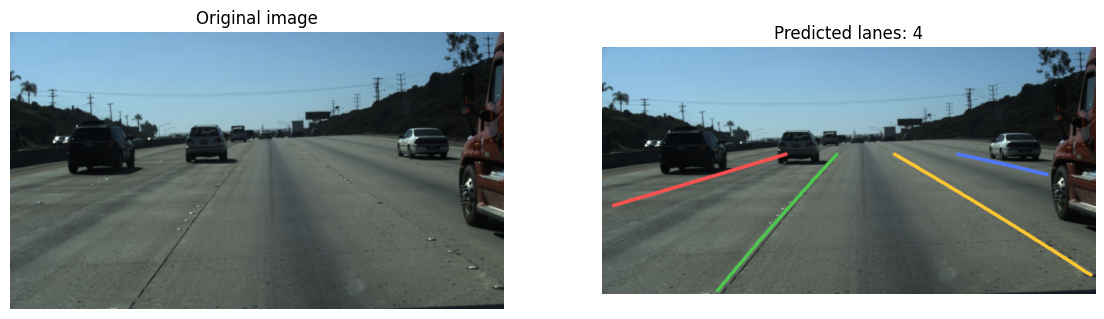

Raw file: clips/0313-1/6040/20.jpg
Predicted lane count: 4
Ground truth lane count: 4


In [ ]:
import matplotlib.pyplot as plt

sample_index = 0
prediction, lanes, image_rgb = predict_one(annotations[sample_index])

# Draw lanes on the resized image used by the model for easier postprocess visualization.
resized_rgb = cv2.resize(image_rgb, (cfg.IMAGE_WIDTH, cfg.IMAGE_HEIGHT))
annotated = draw_lanes(resized_rgb, lanes, thickness=4)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Original image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(annotated)
plt.title(f"Predicted lanes: {len(prediction['lanes'])}")
plt.axis('off')
plt.show()

print('Raw file:', prediction['raw_file'])
print('Predicted lane count:', len(prediction['lanes']))
print('Ground truth lane count:', len(annotations[sample_index]['lanes']))

## Report Table Helper

In [ ]:
report_row = pd.DataFrame([
    {
        'Model': architecture,
        'Accuracy': summary_metrics['accuracy'] * 100,
        'FP': summary_metrics['fp'],
        'FN': summary_metrics['fn'],
        'FPS': summary_metrics['fps'],
    }
])
report_row

,Model,Accuracy,FP,FN,FPS
0,LaneNetResNet34,77.166686,0.487231,0.500414,23.462325


## CULane Evaluation

This section evaluates CULane-trained checkpoints with CULane-style lane-level metrics. CULane uses an IoU-based matching protocol: predicted and ground-truth lanes are rasterized as fixed-width lane lines, matched if their IoU is above a threshold, and then Precision, Recall, and F1 score are calculated from TP, FP, and FN.

In [12]:
# =========================
# CULane configuration and archive extraction
# FAST_CULANE_LOADER_VERSION
# =========================
import tarfile
import zipfile
import shutil
import os

DRIVE_CULANE_DIR = Path('/content/drive/MyDrive/CULane_Dataset')
CULANE_ROOT = Path('/content/CULane')
CULANE_ROOT.mkdir(parents=True, exist_ok=True)

CULANE_CHECKPOINT_PATH = Path('/content/drive/MyDrive/Lane_Detection_Project/checkpoints/6/best.pt')
CULANE_OUTPUT_DIR = Path('/content/drive/MyDrive/Lane_Detection_Project/culane_test_outputs')
CULANE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CULANE_ARCHIVES = [
    'video_example.zip',
    'list.tar.gz',
    'annotations_new.tar.gz',
    'laneseg_label_w16_test.zip',
]

# After the archives are extracted once, set this to False.
# Re-extracting is slow and unnecessary for repeated metric runs.
EXTRACT_CULANE_ARCHIVES = True

CULANE_ARCHIVES = [
    'video_example.zip',
    'list.tar.gz',
    'annotations_new.tar.gz',
    'laneseg_label_w16_test.zip',
    'driver_100_30frame.tar.gz',
    'driver_37_30frame.tar.gz',
    'driver_193_90frame.tar.gz',
    'driver_161_90frame.tar.gz',
    'driver_182_30frame.tar.gz',
    'driver_23_30frame.tar.gz',
]

CULANE_MAX_SAMPLES = None       # set to None for full CULane evaluation
CULANE_IOU_THRESHOLD = 0.5
CULANE_LANE_WIDTH = 30

CULANE_POSTPROCESS_KWARGS = dict(
    min_blob_pixels=30,
    lane_probability_threshold=0.95,
    horizon_min_pixels=12,
    horizon_padding=20,
    eps=0.35,
    min_samples=20,
    spatial_weight=0.5,
    clustering_mode='embedding_spatial',
    min_pixels=100,
    poly_degree=2,
)


def extract_archive(archive_path, output_dir):
    print('Extracting:', archive_path.name)
    if archive_path.name.endswith('.tar.gz'):
        with tarfile.open(archive_path, 'r:gz') as tar:
            tar.extractall(output_dir)
    elif archive_path.suffix == '.zip':
        with zipfile.ZipFile(archive_path, 'r') as zip_file:
            zip_file.extractall(output_dir)
    else:
        print('Skipping unsupported archive:', archive_path)


def prepare_culane_archives():
    local_archive_dir = Path('/content/culane_archives')
    local_archive_dir.mkdir(parents=True, exist_ok=True)
    for archive_name in CULANE_ARCHIVES:
        drive_archive = DRIVE_CULANE_DIR / archive_name
        local_archive = local_archive_dir / archive_name
        if not drive_archive.exists():
            print('[WARN] Missing on Drive:', drive_archive)
            continue
        if not local_archive.exists() or local_archive.stat().st_size != drive_archive.stat().st_size:
            print('Copying:', archive_name)
            shutil.copy2(drive_archive, local_archive)
        else:
            print('Already copied:', archive_name)
        extract_archive(local_archive, CULANE_ROOT)


if EXTRACT_CULANE_ARCHIVES:
    prepare_culane_archives()

# Fast sanity checks only. Full recursive counts over CULane can take many minutes.
print('CULane root exists:', CULANE_ROOT.exists(), CULANE_ROOT)
print('CULane checkpoint exists:', CULANE_CHECKPOINT_PATH.exists(), CULANE_CHECKPOINT_PATH)
print('Candidate split files:')
for candidate in CULANE_LIST_CANDIDATES:
    print(' ', candidate, candidate.exists())

print('Top-level CULane folders/files:')
for child in sorted(CULANE_ROOT.iterdir())[:30]:
    print(' ', child)


Already copied: video_example.zip
Extracting: video_example.zip
Already copied: list.tar.gz
Extracting: list.tar.gz
Already copied: annotations_new.tar.gz
Extracting: annotations_new.tar.gz


/tmp/ipykernel_14159/1372048297.py:64: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(output_dir)


Already copied: laneseg_label_w16_test.zip
Extracting: laneseg_label_w16_test.zip
Copying: driver_100_30frame.tar.gz
Extracting: driver_100_30frame.tar.gz
Copying: driver_37_30frame.tar.gz
Extracting: driver_37_30frame.tar.gz
Copying: driver_193_90frame.tar.gz
Extracting: driver_193_90frame.tar.gz
Copying: driver_161_90frame.tar.gz
Extracting: driver_161_90frame.tar.gz
Copying: driver_182_30frame.tar.gz
Extracting: driver_182_30frame.tar.gz
Copying: driver_23_30frame.tar.gz
Extracting: driver_23_30frame.tar.gz
CULane root exists: True /content/CULane
CULane checkpoint exists: True /content/drive/MyDrive/Lane_Detection_Project/checkpoints/6/best.pt
Candidate split files:
  /content/CULane/list/test.txt True
  /content/CULane/list/test_gt.txt False
  /content/CULane/list/val_gt.txt True
Top-level CULane folders/files:
  /content/CULane/05081544_0305
  /content/CULane/driver_100_30frame
  /content/CULane/driver_161_90frame
  /content/CULane/driver_182_30frame
  /content/CULane/driver_193_

In [13]:
def clean_culane_rel_path(path_text):
    return path_text.strip().replace('\\', '/').lstrip('/')


def culane_image_to_line_label(image_rel):
    image_rel = clean_culane_rel_path(image_rel)
    return str(Path(image_rel).with_suffix('.lines.txt'))


def resolve_culane_path_fast(rel_path):
    rel_path = clean_culane_rel_path(rel_path)
    candidates = [
        CULANE_ROOT / rel_path,
        CULANE_ROOT / 'test' / rel_path,
        CULANE_ROOT / 'video_example' / rel_path,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]


def find_culane_split_file_fast():
    for candidate in CULANE_LIST_CANDIDATES:
        if candidate.exists():
            return candidate

    # Bounded fallback: check only common direct locations. Do not recursively scan.
    direct_candidates = [
        CULANE_ROOT / 'test.txt',
        CULANE_ROOT / 'test_gt.txt',
        CULANE_ROOT / 'val_gt.txt',
        CULANE_ROOT / 'list' / 'test.txt',
        CULANE_ROOT / 'list' / 'test_gt.txt',
        CULANE_ROOT / 'list' / 'val_gt.txt',
    ]
    for candidate in direct_candidates:
        if candidate.exists():
            return candidate
    return None


def read_culane_split_fast(split_file, max_samples=None):
    rows = []
    with open(split_file, 'r') as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            image_rel = clean_culane_rel_path(parts[0])
            label_rel = culane_image_to_line_label(image_rel)
            rows.append({
                'image_rel': image_rel,
                'image_path': resolve_culane_path_fast(image_rel),
                'label_rel': label_rel,
                'label_path': resolve_culane_path_fast(label_rel),
            })
            if max_samples is not None and len(rows) >= max_samples:
                break
    return rows


def discover_culane_images_fast(max_samples=None):
    # Only use this if no split file exists. os.walk stops as soon as enough rows are found.
    rows = []
    for root, _, files in os.walk(CULANE_ROOT):
        for file_name in files:
            if not file_name.endswith('.jpg'):
                continue
            image_path = Path(root) / file_name
            if 'laneseg_label' in str(image_path):
                continue
            label_path = image_path.with_suffix('.lines.txt')
            if not label_path.exists():
                continue
            rows.append({
                'image_rel': image_path.relative_to(CULANE_ROOT).as_posix(),
                'image_path': image_path,
                'label_rel': label_path.relative_to(CULANE_ROOT).as_posix(),
                'label_path': label_path,
            })
            if max_samples is not None and len(rows) >= max_samples:
                return rows
    return rows


def load_culane_rows(max_samples=None):
    split_file = find_culane_split_file_fast()
    if split_file is not None:
        print('Using CULane split file:', split_file)
        rows = read_culane_split_fast(split_file, max_samples=max_samples)
    else:
        print('No split file found. Discovering images with early stop.')
        rows = discover_culane_images_fast(max_samples=max_samples)

    missing_examples = []
    valid_rows = []
    for row in rows:
        if row['image_path'].exists() and row['label_path'].exists():
            valid_rows.append(row)
        elif len(missing_examples) < 5:
            missing_examples.append(row)

    if missing_examples:
        print('Examples of rows with missing image or label:')
        for row in missing_examples:
            print(' image:', row['image_path'], row['image_path'].exists())
            print(' label:', row['label_path'], row['label_path'].exists())

    return valid_rows


culane_rows = load_culane_rows(CULANE_MAX_SAMPLES)
print('CULane samples selected:', len(culane_rows))
if culane_rows:
    print(culane_rows[0])
else:
    print('No valid CULane rows found. If archives are not extracted yet, set EXTRACT_CULANE_ARCHIVES=True and rerun the config cell once.')


Using CULane split file: /content/CULane/list/test.txt
CULane samples selected: 34680
{'image_rel': 'driver_100_30frame/05251517_0433.MP4/00000.jpg', 'image_path': PosixPath('/content/CULane/driver_100_30frame/05251517_0433.MP4/00000.jpg'), 'label_rel': 'driver_100_30frame/05251517_0433.MP4/00000.lines.txt', 'label_path': PosixPath('/content/CULane/driver_100_30frame/05251517_0433.MP4/00000.lines.txt')}


In [14]:
def parse_culane_lines(label_path):
    lanes = []
    for line in label_path.read_text().splitlines():
        values = [float(value) for value in line.strip().split()]
        if len(values) < 4:
            continue
        points = []
        for x, y in zip(values[0::2], values[1::2]):
            if x >= 0 and y >= 0:
                points.append((float(x), float(y)))
        if len(points) >= 2:
            lanes.append(sorted(points, key=lambda point: point[1]))
    return lanes


def culane_prediction_points(lanes, original_width, original_height, point_step=4):
    pred_lanes = []
    scale_x = original_width / cfg.IMAGE_WIDTH
    scale_y = original_height / cfg.IMAGE_HEIGHT

    for lane in lanes:
        y_min = max(0, int(lane['y_min']))
        y_max = min(cfg.IMAGE_HEIGHT - 1, int(lane['y_max']))
        if y_max <= y_min:
            continue
        ys_resized = np.arange(y_min, y_max + 1, point_step)
        xs_resized = np.polyval(lane['poly'], ys_resized)
        points = []
        for x_resized, y_resized in zip(xs_resized, ys_resized):
            x_original = float(x_resized * scale_x)
            y_original = float(y_resized * scale_y)
            if 0 <= x_original < original_width and 0 <= y_original < original_height:
                points.append((x_original, y_original))
        if len(points) >= 2:
            pred_lanes.append(points)
    return pred_lanes


def rasterize_lane(points, height, width, lane_width=30):
    canvas = np.zeros((height, width), dtype=np.uint8)
    if len(points) < 2:
        return canvas.astype(bool)
    pts = np.array(points, dtype=np.int32).reshape(-1, 1, 2)
    cv2.polylines(canvas, [pts], isClosed=False, color=1, thickness=lane_width)
    return canvas.astype(bool)


def lane_iou(pred_points, gt_points, height, width, lane_width=30):
    pred_mask = rasterize_lane(pred_points, height, width, lane_width)
    gt_mask = rasterize_lane(gt_points, height, width, lane_width)
    union = np.logical_or(pred_mask, gt_mask).sum()
    if union == 0:
        return 0.0
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    return float(intersection / union)


def match_culane_lanes(pred_lanes, gt_lanes, height, width, iou_threshold=0.5, lane_width=30):
    pairs = []
    for pred_idx, pred_lane in enumerate(pred_lanes):
        for gt_idx, gt_lane in enumerate(gt_lanes):
            iou = lane_iou(pred_lane, gt_lane, height, width, lane_width)
            if iou >= iou_threshold:
                pairs.append((iou, pred_idx, gt_idx))

    pairs.sort(reverse=True, key=lambda item: item[0])
    matched_preds = set()
    matched_gts = set()
    for _, pred_idx, gt_idx in pairs:
        if pred_idx in matched_preds or gt_idx in matched_gts:
            continue
        matched_preds.add(pred_idx)
        matched_gts.add(gt_idx)

    tp = len(matched_preds)
    fp = len(pred_lanes) - tp
    fn = len(gt_lanes) - tp
    return tp, fp, fn

In [18]:
culane_model, culane_architecture, culane_checkpoint_epoch = load_lanenet_checkpoint(
    CULANE_CHECKPOINT_PATH,
    DEVICE,
)
print('CULane architecture:', culane_architecture)
print('CULane checkpoint epoch:', culane_checkpoint_epoch)

CULane architecture: LaneNetResNet34
CULane checkpoint epoch: 14


In [19]:
@torch.no_grad()
def predict_culane_one(row):
    image_bgr = cv2.imread(str(row['image_path']))
    if image_bgr is None:
        raise RuntimeError(f"Failed to read image: {row['image_path']}")

    original_height, original_width = image_bgr.shape[:2]
    x, _ = preprocess_image_for_model(image_bgr)
    x = x.to(DEVICE)

    start = time.perf_counter()
    binary_logits, embedding = culane_model(x)
    if DEVICE == 'cuda':
        torch.cuda.synchronize()
    runtime_ms = (time.perf_counter() - start) * 1000.0

    binary_np = binary_logits.squeeze(0).detach().cpu().numpy()
    embedding_np = embedding.squeeze(0).detach().cpu().numpy()
    supported_postprocess_keys = inspect.signature(my_postprocess).parameters.keys()
    postprocess_kwargs = {
        key: value
        for key, value in CULANE_POSTPROCESS_KWARGS.items()
        if key in supported_postprocess_keys
    }
    fitted_lanes = my_postprocess(binary_np, embedding_np, **postprocess_kwargs)
    pred_lanes = culane_prediction_points(
        fitted_lanes,
        original_width=original_width,
        original_height=original_height,
    )
    gt_lanes = parse_culane_lines(row['label_path'])
    tp, fp, fn = match_culane_lanes(
        pred_lanes,
        gt_lanes,
        height=original_height,
        width=original_width,
        iou_threshold=CULANE_IOU_THRESHOLD,
        lane_width=CULANE_LANE_WIDTH,
    )
    return {
        'image_rel': row['image_rel'],
        'pred_lanes': pred_lanes,
        'gt_lanes': gt_lanes,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'runtime_ms': runtime_ms,
    }

In [22]:
culane_results = []
for row in tqdm(culane_rows, desc='Testing CULane'):
    culane_results.append(predict_culane_one(row))

total_tp = sum(result['tp'] for result in culane_results)
total_fp = sum(result['fp'] for result in culane_results)
total_fn = sum(result['fn'] for result in culane_results)

culane_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
culane_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
culane_f1 = 2 * culane_precision * culane_recall / (culane_precision + culane_recall) if (culane_precision + culane_recall) > 0 else 0.0
culane_avg_runtime_ms = float(np.mean([result['runtime_ms'] for result in culane_results])) if culane_results else 0.0
culane_fps = 1000.0 / culane_avg_runtime_ms if culane_avg_runtime_ms > 0 else 0.0

culane_summary = {
    'architecture': culane_architecture,
    'checkpoint': str(CULANE_CHECKPOINT_PATH),
    'checkpoint_epoch': culane_checkpoint_epoch,
    'num_samples': len(culane_results),
    'iou_threshold': CULANE_IOU_THRESHOLD,
    'lane_width': CULANE_LANE_WIDTH,
    'tp': int(total_tp),
    'fp': int(total_fp),
    'fn': int(total_fn),
    'precision': float(culane_precision),
    'recall': float(culane_recall),
    'f1': float(culane_f1),
    'avg_runtime_ms': culane_avg_runtime_ms,
    'fps': float(culane_fps),
}
culane_summary

Testing CULane:   0%|          | 0/34680 [00:00<?, ?it/s]

{'architecture': 'LaneNetResNet34',
 'checkpoint': '/content/drive/MyDrive/Lane_Detection_Project/checkpoints/6/best.pt',
 'checkpoint_epoch': 14,
 'num_samples': 34680,
 'iou_threshold': 0.5,
 'lane_width': 30,
 'tp': 73576,
 'fp': 31932,
 'fn': 31309,
 'precision': 0.6973499639837737,
 'recall': 0.7014921104066358,
 'f1': 0.6994149044882672,
 'avg_runtime_ms': 40.198066373300115,
 'fps': 24.87681846966172}

In [23]:
print(f"CULane Precision: {culane_summary['precision'] * 100:.2f}")
print(f"CULane Recall: {culane_summary['recall'] * 100:.2f}")
print(f"CULane F1: {culane_summary['f1'] * 100:.2f}")
print(f"TP: {culane_summary['tp']}  FP: {culane_summary['fp']}  FN: {culane_summary['fn']}")
print(f"Average runtime: {culane_summary['avg_runtime_ms']:.2f} ms/frame")
print(f"FPS: {culane_summary['fps']:.2f}")

CULane Precision: 69.73
CULane Recall: 70.15
CULane F1: 69.94
TP: 73576  FP: 31932  FN: 31309
Average runtime: 40.20 ms/frame
FPS: 24.88


In [24]:
culane_prediction_path = CULANE_OUTPUT_DIR / 'culane_predictions.json'
culane_summary_path = CULANE_OUTPUT_DIR / 'culane_summary.json'
culane_per_image_path = CULANE_OUTPUT_DIR / 'culane_per_image_metrics.csv'

serializable_predictions = []
per_image_rows = []
for result in culane_results:
    serializable_predictions.append({
        'image_rel': result['image_rel'],
        'pred_lanes': result['pred_lanes'],
        'gt_lanes': result['gt_lanes'],
        'tp': result['tp'],
        'fp': result['fp'],
        'fn': result['fn'],
        'runtime_ms': result['runtime_ms'],
    })
    precision = result['tp'] / (result['tp'] + result['fp']) if (result['tp'] + result['fp']) > 0 else 0.0
    recall = result['tp'] / (result['tp'] + result['fn']) if (result['tp'] + result['fn']) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    per_image_rows.append({
        'image_rel': result['image_rel'],
        'tp': result['tp'],
        'fp': result['fp'],
        'fn': result['fn'],
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'runtime_ms': result['runtime_ms'],
    })

with open(culane_prediction_path, 'w') as file:
    for prediction in serializable_predictions:
        file.write(json.dumps(prediction) + '\n')

with open(culane_summary_path, 'w') as file:
    json.dump(culane_summary, file, indent=2)

pd.DataFrame(per_image_rows).to_csv(culane_per_image_path, index=False)
print('Saved CULane predictions:', culane_prediction_path)
print('Saved CULane summary:', culane_summary_path)
print('Saved CULane per-image metrics:', culane_per_image_path)

Saved CULane predictions: /content/drive/MyDrive/Lane_Detection_Project/culane_test_outputs/culane_predictions.json
Saved CULane summary: /content/drive/MyDrive/Lane_Detection_Project/culane_test_outputs/culane_summary.json
Saved CULane per-image metrics: /content/drive/MyDrive/Lane_Detection_Project/culane_test_outputs/culane_per_image_metrics.csv


In [25]:
# Visual check for CULane predictions.
culane_sample_index = 0
sample_result = culane_results[culane_sample_index]
sample_row = culane_rows[culane_sample_index]
image_bgr = cv2.imread(str(sample_row['image_path']))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

pred_overlay = image_rgb.copy()
gt_overlay = image_rgb.copy()

for lane in sample_result['pred_lanes']:
    pts = np.array(lane, dtype=np.int32).reshape(-1, 1, 2)
    cv2.polylines(pred_overlay, [pts], isClosed=False, color=(255, 0, 0), thickness=8)

for lane in sample_result['gt_lanes']:
    pts = np.array(lane, dtype=np.int32).reshape(-1, 1, 2)
    cv2.polylines(gt_overlay, [pts], isClosed=False, color=(0, 255, 0), thickness=8)

plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('Input')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(gt_overlay)
plt.title('Ground truth lanes')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(pred_overlay)
plt.title('Predicted lanes')
plt.axis('off')
plt.show()

print('Image:', sample_result['image_rel'])
print('Pred lanes:', len(sample_result['pred_lanes']))
print('GT lanes:', len(sample_result['gt_lanes']))
print('TP/FP/FN:', sample_result['tp'], sample_result['fp'], sample_result['fn'])

NameError: name 'plt' is not defined

In [26]:
culane_report_row = pd.DataFrame([
    {
        'Model': culane_architecture,
        'Precision': culane_summary['precision'] * 100,
        'Recall': culane_summary['recall'] * 100,
        'F1': culane_summary['f1'] * 100,
        'TP': culane_summary['tp'],
        'FP': culane_summary['fp'],
        'FN': culane_summary['fn'],
        'FPS': culane_summary['fps'],
    }
])
culane_report_row

,Model,Precision,Recall,F1,TP,FP,FN,FPS
0,LaneNetResNet34,69.734996,70.149211,69.94149,73576,31932,31309,24.876818
